In [ ]:
import os
import glob
import time
import random
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers, Sequential
from tensorflow.keras.utils import plot_model

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [2]:
warnings.filterwarnings("ignore")
plt.style.use('dark_background')

In [19]:
class CFG:
    EPOCHS = 10
    BATCH_SIZE = 32
    SEED = 42
    TF_SEED = 768
    HEIGHT = 224
    WIDTH = 224
    CHANNELS = 3
    IMAGE_SIZE = (224, 224, 3)

In [5]:
def seed_everything(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything(CFG.SEED)

In [30]:
# Download latest version and move to project directory
import kagglehub
import shutil

# Download to default cache location first
temp_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Set custom download path to your project folder
custom_path = "/Users/anixas./Desktop/Projects/prsf_26/dataset"
os.makedirs(custom_path, exist_ok=True)

# Copy the dataset to your project folder
if os.path.exists(temp_path):
    dataset_name = os.path.basename(temp_path)
    final_path = os.path.join(custom_path, dataset_name)

    if not os.path.exists(final_path):
        shutil.copytree(temp_path, final_path)
        print(f"Dataset copied to: {final_path}")
    else:
        print(f"Dataset already exists at: {final_path}")

    path = final_path
else:
    print("Download failed")
    path = temp_path

print("Path to dataset files:", path)

Dataset already exists at: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Path to dataset files: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Dataset already exists at: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Path to dataset files: /Users/anixas./Desktop/Projects/prsf_26/dataset/2


In [29]:
# Define paths based on custom download location
DATASET_PATH = path + "/"
TRAIN_PATH = path + '/chest_xray/train/'
VAL_PATH = path + '/chest_xray/val/'
TEST_PATH = path + '/chest_xray/test/'

# Checking dataset and locations
print(f"Dataset will be downloaded to: {path}")
print(f"Train path: {TRAIN_PATH}")
print(f"Val path: {VAL_PATH}")
print(f"Test path: {TEST_PATH}")

Dataset will be downloaded to: /Users/anixas./Desktop/Projects/prsf_26/dataset/2
Train path: /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/train/
Val path: /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/val/
Test path: /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test/


In [13]:
# Generate a summary of the dataset
print('DATASET SUMMARY')
print('========================\n')
for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")
print('\n========================')

DATASET SUMMARY

There are 1 directories and 0 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/
There are 5 directories and 0 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray
There are 2 directories and 0 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test
There are 0 directories and 390 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test/PNEUMONIA
There are 0 directories and 234 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/test/NORMAL
There are 3 directories and 1 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/chest_xray
There are 2 directories and 1 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/chest_xray/test
There are 0 directories and 390 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/chest_xray/chest_xray/test/PNEUMONIA
There are 0 directories and 234 images in /Users/anixas./Desktop/Projects/prsf_26/dataset/2/ch

In [14]:
# time
train_images = glob.glob(f"{TRAIN_PATH}**/*.jpeg")
val_images = glob.glob(f"{VAL_PATH}**/*.jpeg")
test_images = glob.glob(f"{TEST_PATH}**/*.jpeg")

In [15]:
train_size = len(train_images)
val_size = len(val_images)
test_size = len(test_images)
total = train_size + val_size + test_size

# View the counts
print(f'train samples count:\t\t{train_size}')
print(f'dev/validation samples count:\t{val_size}')
print(f'test samples count:\t\t{test_size}')
print('=======================================')
print(f'TOTAL:\t\t\t\t{total}')

train samples count:		5216
dev/validation samples count:	16
test samples count:		624
TOTAL:				5856


In [16]:
def generate_labels(image_paths):
    labels = []
    for _ in image_paths:
        if ('PNEUMONIA' in _.replace('chest-xray-pneumonia', '')):
            labels.append('PNEUMONIA')
        else:
            labels.append('NORMAL')
            
    return labels

def build_df(image_paths, labels):
    df = pd.DataFrame({
        'image_path': image_paths,
        'label': generate_labels(labels)
    })
    df['label_encoded'] = df.apply(lambda row: 0 if row.label == 'NORMAL' else 1, axis=1)
    
    return df.sample(frac=1, random_state=CFG.SEED).reset_index()

In [20]:
# Build the DataFrames
train_df = build_df(train_images, generate_labels(train_images))
val_df = build_df(val_images, generate_labels(val_images))
test_df = build_df(test_images, generate_labels(test_images))

In [21]:
# Have a look at val_df
val_df

,index,image_path,label,label_encoded
0,0,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
1,1,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
2,5,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
3,14,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
4,13,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
5,11,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
6,8,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
7,9,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
8,2,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
9,15,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0


In [22]:
def _load(image_path):
    # Read and decode an image file to a uint8 tensor
    image = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image, channels=3)
    
    # Resize image
    image = tf.image.resize(image, [CFG.HEIGHT, CFG.WIDTH],
                            method=tf.image.ResizeMethod.LANCZOS3)
    
    # Convert image dtype to float32 and NORMALIZE!!!
    image = tf.cast(image, tf.float32)/255.
    
    # Return image
    return image

def view_sample(image, label, color_map='gray', fig_size=(8, 10)):
    plt.figure(figsize=fig_size)
    plt.imshow(image, cmap=color_map)
    plt.title(f'Label: {label}', fontsize=16)
    return

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.10908511..1.2308967].


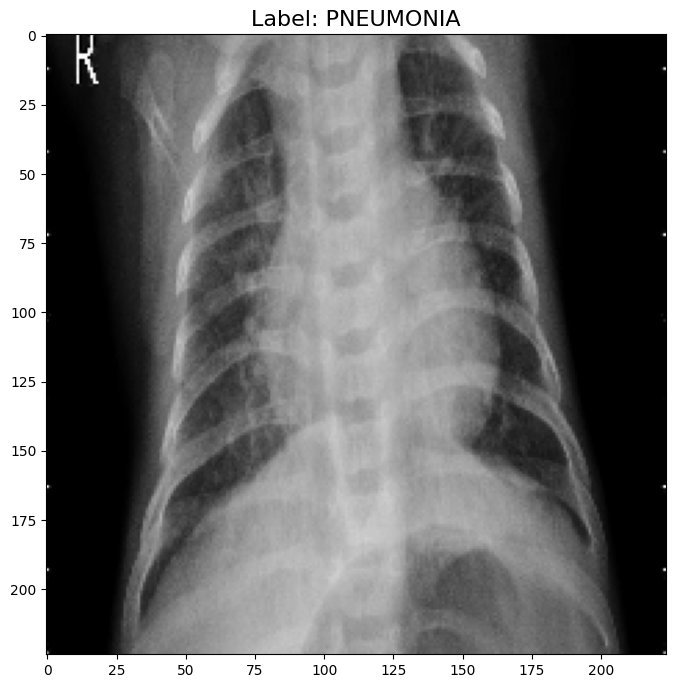

In [23]:
# Select random sample from train_df
idx = random.sample(train_df.index.to_list(), 1)[0]

# Load the random sample and label
sample_image, sample_label = _load(train_df.image_path[idx]), train_df.label[idx]

# View the random sample
view_sample(sample_image, sample_label)

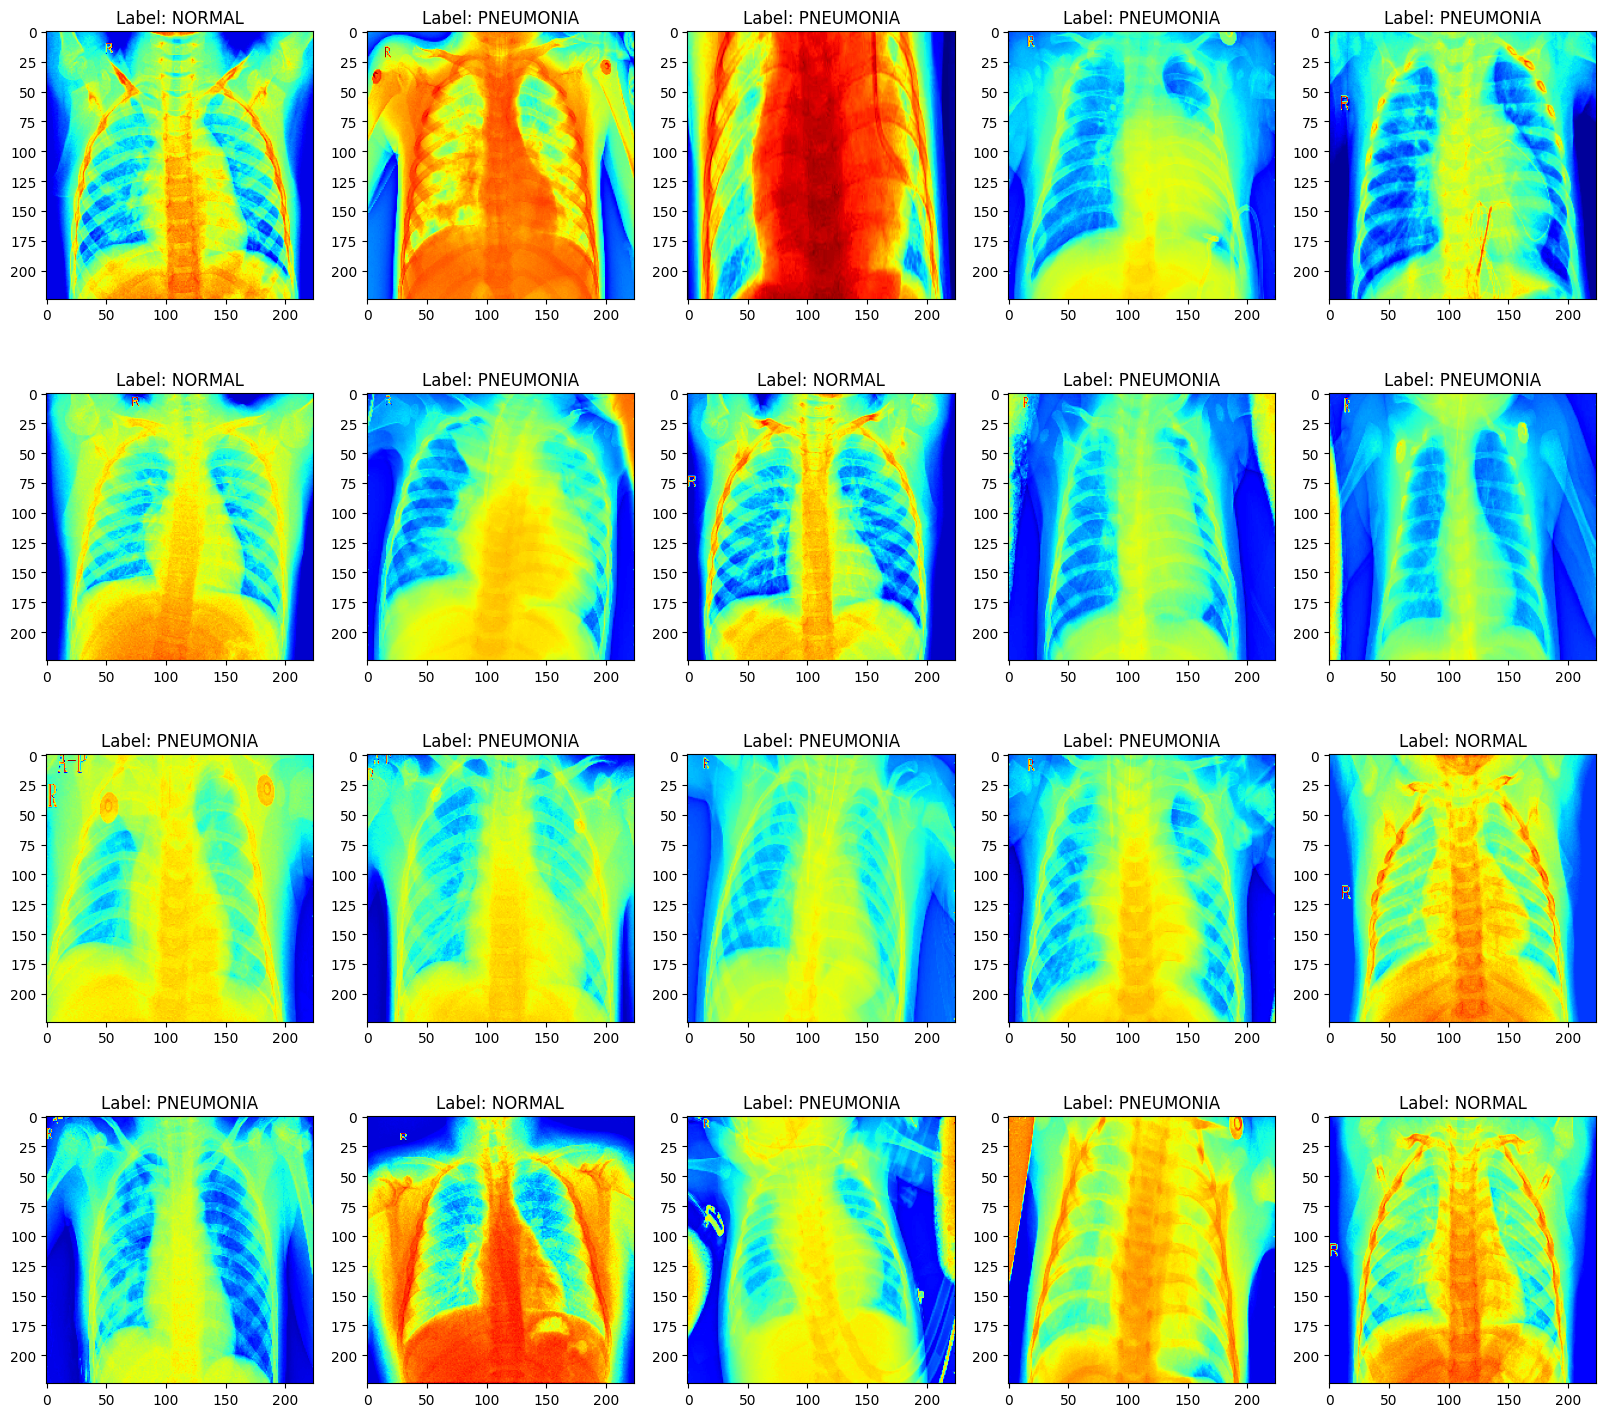

In [24]:
def view_mulitiple_samples(df, sample_loader, count=10, color_map='gray', fig_size=(14, 10)):
    rows = count//5
    if count%5 > 0:
        rows +=1
    
    idx = random.sample(df.index.to_list(), count)    
    fig = plt.figure(figsize=fig_size)

    for column, _ in enumerate(idx):
        plt.subplot(rows, 5, column+1)
        plt.title(f'Label: {df.label[_]}')
        plt.imshow(tf.image.rgb_to_grayscale(sample_loader(df.image_path[_])), cmap=color_map);
    
    return

view_mulitiple_samples(train_df, _load, 
                       count=20, color_map='jet', 
                       fig_size=(20, 18))

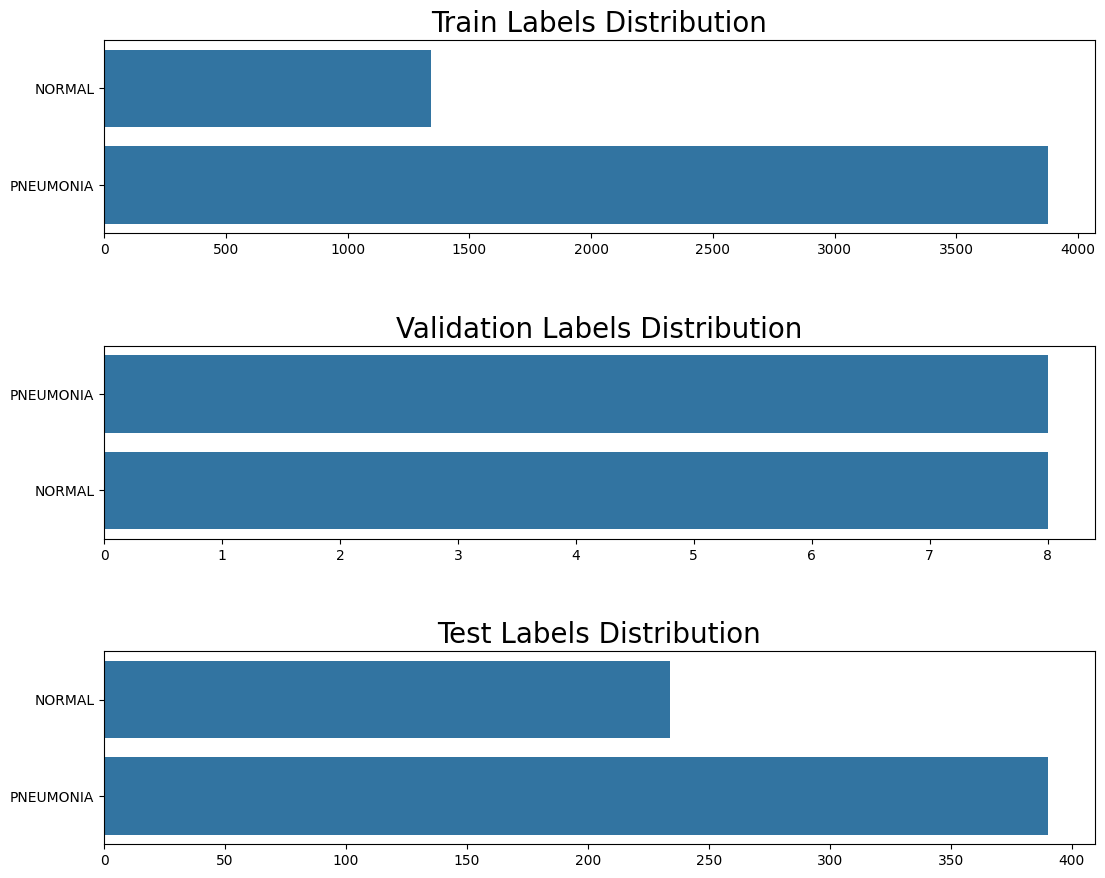

In [28]:
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(12, 10))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# Plot Train Class Distribution
ax1.set_title('Train Labels Distribution', fontsize=20)
train_distribution = train_df['label'].value_counts().sort_values()

sns.barplot(x=train_distribution.values,
            y=list(train_distribution.keys()),
            orient="h",
            ax=ax1)

# Plot Validation Class Distribution
ax2.set_title('Validation Labels Distribution', fontsize=20)
val_distribution = val_df['label'].value_counts().sort_values()

sns.barplot(x=val_distribution.values,
            y=list(val_distribution.keys()),
            orient="h",
            ax=ax2)

# Plot Test Class Distribution
ax3.set_title('Test Labels Distribution', fontsize=20)
test_distribution = test_df['label'].value_counts().sort_values()

sns.barplot(x=test_distribution.values,
            y=list(test_distribution.keys()),
            orient="h",
            ax=ax3);

In [26]:
# new train and validation split
train_pneumonia = train_df[train_df['label'] == 'PNEUMONIA']
train_normal = train_df[train_df['label'] == 'NORMAL']

# Create chronological ordered split
validation_size = 0.2

# Get new validation samples
val_pneumonia = train_pneumonia[:int(len(train_pneumonia) * validation_size)]
val_normal = train_normal[:int(len(train_normal) * validation_size)]

# Get new train samples
train_new_pneumonia = train_pneumonia[int(len(train_pneumonia) * validation_size):]
train_new_normal = train_normal[int(len(train_normal) * validation_size):]

# Create new validation set and shuffle
val_split_df = pd.concat([val_df, val_pneumonia, val_normal], axis=0) \
                 .sample(frac=1, random_state=CFG.SEED) \
                 .reset_index(drop=True)

# Create new train set and shuffle
train_split_df = pd.concat([train_new_pneumonia, train_new_normal], axis=0) \
                   .sample(frac=1, random_state=CFG.SEED) \
                   .reset_index(drop=True) 

In [27]:
# View fisrt 10 samples from the new validation set
val_split_df.head(10)

,index,image_path,label,label_encoded
0,2380,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
1,803,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
2,3307,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
3,2478,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
4,3939,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
5,4559,/Users/anixas./Desktop/Projects/prsf_26/datase...,NORMAL,0
6,1890,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
7,745,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
8,1745,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1
9,1032,/Users/anixas./Desktop/Projects/prsf_26/datase...,PNEUMONIA,1


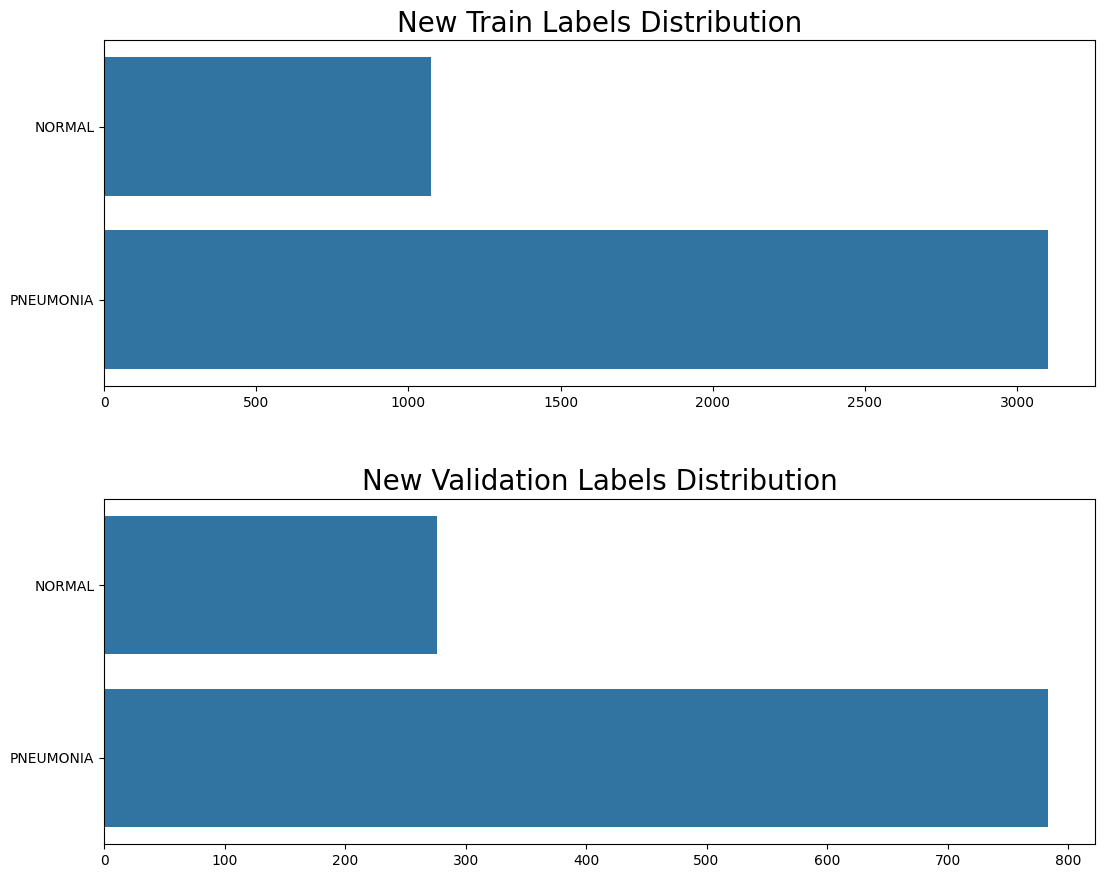

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 10))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# Plot Train Class Distribution
ax1.set_title('New Train Labels Distribution', fontsize=20)
train_split_distribution = train_split_df['label'].value_counts().sort_values()
sns.barplot(x=train_split_distribution.values,
            y=list(train_split_distribution.keys()),
            orient="h",
            ax=ax1);

# Plot Validation Class Distribution
ax2.set_title('New Validation Labels Distribution', fontsize=20)
val_split_distribution = val_split_df['label'].value_counts().sort_values()
sns.barplot(x=val_split_distribution.values,
            y=list(val_split_distribution.keys()),
            orient="h",
            ax=ax2);

In [ ]:
# constructing dataset input pipeline with tf.data api

